In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/YOLO_MS671_2026

/content/drive/MyDrive/YOLO_MS671_2026


Processamento via: cuda
Iniciando leitura de: yolov3.weights
Sucesso! 62001757 parâmetros carregados perfeitamente.
Processando imagem: img/dog.jpg


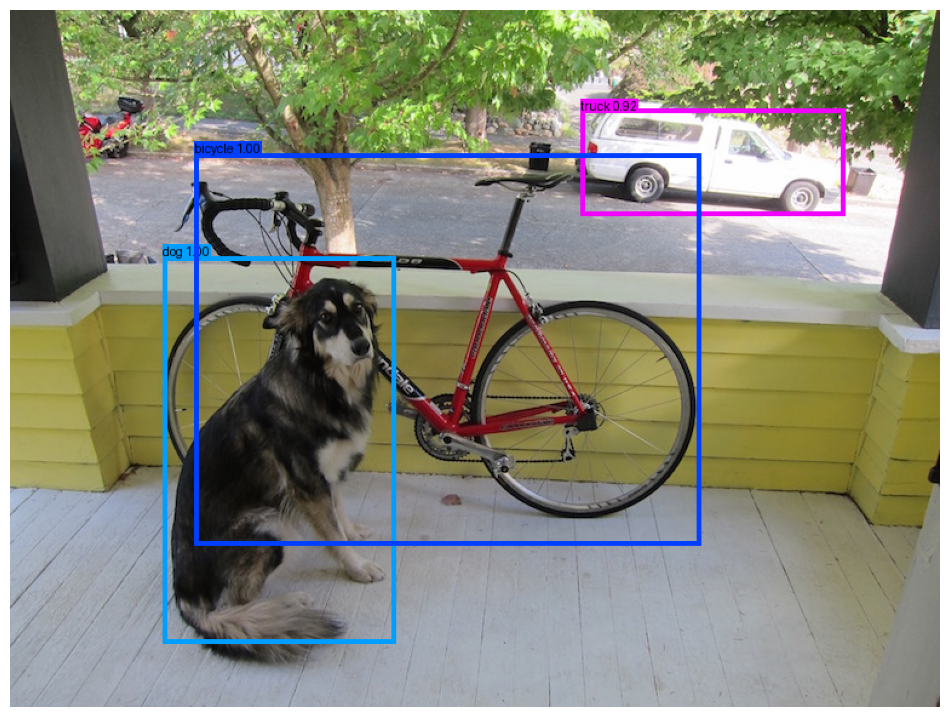

In [ ]:
import os
import random
import colorsys
import numpy as np
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from utils import manual_nms # função manual de NMS e IoU que devem implementar

# ==========================================
# 1. ÂNCORAS DO YOLOV3 (COCO)
# ==========================================
# O YOLOv3 divide a detecção em 3 escalas diferentes (Pequenos, Médios, Grandes)
YOLOV3_ANCHORS = [
    [(116, 90), (156, 198), (373, 326)],  # Escala 1 (13x13) - Objetos Maiores
    [(30, 61), (62, 45), (59, 119)],      # Escala 2 (26x26) - Objetos Médios
    [(10, 13), (16, 30), (33, 23)]        # Escala 3 (52x52) - Objetos Menores
]

# ==========================================
# 2. FUNÇÕES DE UTILIDADE E PRÉ-PROCESSAMENTO
# ==========================================
def read_classes(classes_path):
    with open(classes_path) as f:
        return [c.strip() for c in f.readlines()]

def generate_colors(class_names):
    hsv_tuples = [(x / len(class_names), 1., 1.) for x in range(len(class_names))]
    colors = list(map(lambda x: colorsys.hsv_to_rgb(*x), hsv_tuples))
    colors = list(map(lambda x: (int(x[0] * 255), int(x[1] * 255), int(x[2] * 255)), colors))
    random.seed(10101)
    random.shuffle(colors)
    random.seed(None)
    return colors

def letterbox_image(image, size=(416, 416)):
    """Redimensiona a imagem mantendo a proporção e preenchendo com barras cinzas."""
    iw, ih = image.size
    w, h = size
    # Encontra a escala ideal sem distorcer
    scale = min(w / iw, h / ih)
    nw = int(iw * scale)
    nh = int(ih * scale)

    # Redimensiona mantendo a proporção
    image = image.resize((nw, nh), Image.BICUBIC)

    # Cria um fundo cinza neutro e cola a imagem no centro
    new_image = Image.new('RGB', size, (128, 128, 128))
    new_image.paste(image, ((w - nw) // 2, (h - nh) // 2))
    return new_image

def reverter_escala_caixas(boxes, img_size, original_shape):
    """Remove o efeito do letterbox e reajusta as caixas para o tamanho original da imagem."""
    iw, ih = original_shape
    w, h = img_size
    scale = min(w / iw, h / ih)
    nw, nh = int(iw * scale), int(ih * scale)

    # Calcula o tamanho das barras cinzas no formato normalizado (0 a 1)
    dx = (w - nw) / 2.0 / w
    dy = (h - nh) / 2.0 / h
    scale_w = nw / w
    scale_h = nh / h

    # Remove as barras (Lembrando que o formato é [y_min, x_min, y_max, x_max])
    boxes[:, [0, 2]] = (boxes[:, [0, 2]] - dy) / scale_h
    boxes[:, [1, 3]] = (boxes[:, [1, 3]] - dx) / scale_w

    # Multiplica pelas dimensões exatas da imagem original
    boxes[:, [0, 2]] *= ih # Multiplica o eixo Y pela Altura
    boxes[:, [1, 3]] *= iw # Multiplica o eixo X pela Largura

    return boxes

def scale_boxes(boxes, image_shape):
    height, width = image_shape
    image_dims = torch.tensor([width, height, width, height], dtype=torch.float32, device=boxes.device)
    return boxes * image_dims

def preprocess_image(img_path, model_image_size=(416, 416)):
    # 1. Carrega a imagem original
    image = Image.open(img_path).convert('RGB')

    # 2. Aplica o Letterbox (mantém proporção) em vez de distorcer
    boxed_image = letterbox_image(image, model_image_size)

    # 3. Converte para Tensor
    image_data = np.array(boxed_image, dtype='float32') / 255.0
    image_data = image_data[:, :, ::-1].copy() # RGB para BGR

    image_data = np.transpose(image_data, (2, 0, 1))
    image_data = torch.from_numpy(image_data).unsqueeze(0)

    # Retorna a imagem ORIGINAL (para desenho) e os dados quadrados (para a rede)
    return image, image_data

# ==========================================
# 3. BLOCOS DE CONSTRUÇÃO DA REDE (DARKNET-53)
# ==========================================
class ConvBlock(nn.Module):
    """Bloco base: Convolução -> BatchNorm -> LeakyReLU"""
    def __init__(self, in_c, out_c, k, s, p, bn=True):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, k, s, p, bias=not bn)
        self.bn = nn.BatchNorm2d(out_c, eps=1e-5) if bn else None
        self.act = nn.LeakyReLU(0.1, inplace=True) if bn else None

    def forward(self, x):
        x = self.conv(x)
        if self.bn:
            x = self.act(self.bn(x))
        return x

class ResBlock(nn.Module):
    """Bloco Residual (Atalho de conexão)"""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvBlock(channels, channels // 2, 1, 1, 0)
        self.conv2 = ConvBlock(channels // 2, channels, 3, 1, 1)

    def forward(self, x):
        return x + self.conv2(self.conv1(x))

class YOLOv3(nn.Module):
    """Arquitetura Completa do YOLOv3"""
    def __init__(self, num_classes=80):
        super().__init__()
        self.num_classes = num_classes

        # --- BACKBONE: DARKNET-53 ---
        self.conv1 = ConvBlock(3, 32, 3, 1, 1)
        self.layer1 = self._make_layer(32, 64, 1)
        self.layer2 = self._make_layer(64, 128, 2)
        self.layer3 = self._make_layer(128, 256, 8)  # Rota 1 (Usado na Escala 3)
        self.layer4 = self._make_layer(256, 512, 8)  # Rota 2 (Usado na Escala 2)
        self.layer5 = self._make_layer(512, 1024, 4) # Rota 3 (Fim do Backbone)

        # --- CABEÇALHO 1: Escala 13x13 (Objetos Grandes) ---
        self.head1_1 = self._make_c5(1024, 512)
        self.head1_2 = self._make_yolo_head(512, 1024, num_classes)

        # --- CABEÇALHO 2: Escala 26x26 (Objetos Médios) ---
        self.head2_1 = ConvBlock(512, 256, 1, 1, 0)
        self.upsample1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.head2_2 = self._make_c5(768, 256) # 256 + 512(Rota 2)
        self.head2_3 = self._make_yolo_head(256, 512, num_classes)

        # --- CABEÇALHO 3: Escala 52x52 (Objetos Pequenos) ---
        self.head3_1 = ConvBlock(256, 128, 1, 1, 0)
        self.upsample2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.head3_2 = self._make_c5(384, 128) # 128 + 256(Rota 1)
        self.head3_3 = self._make_yolo_head(128, 256, num_classes)

    def _make_layer(self, in_c, out_c, num_blocks):
        layers = [ConvBlock(in_c, out_c, 3, 2, 1)]
        for _ in range(num_blocks):
            layers.append(ResBlock(out_c))
        return nn.Sequential(*layers)

    def _make_c5(self, in_c, out_c):
        """Bloco de 5 convoluções intercaladas"""
        return nn.Sequential(
            ConvBlock(in_c, out_c, 1, 1, 0),
            ConvBlock(out_c, out_c * 2, 3, 1, 1),
            ConvBlock(out_c * 2, out_c, 1, 1, 0),
            ConvBlock(out_c, out_c * 2, 3, 1, 1),
            ConvBlock(out_c * 2, out_c, 1, 1, 0),
        )

    def _make_yolo_head(self, in_c, out_c, num_classes):
        """Convolução Final Linear sem BatchNorm (Previsão de Caixas)"""
        return nn.Sequential(
            ConvBlock(in_c, out_c, 3, 1, 1),
            nn.Conv2d(out_c, 3 * (5 + num_classes), 1, 1, 0, bias=True)
        )

    def forward(self, x):
        # Passagem pelo Backbone
        x = self.layer2(self.layer1(self.conv1(x)))
        route1 = self.layer3(x)
        route2 = self.layer4(route1)
        x = self.layer5(route2)

        # Escala 1
        x1_5 = self.head1_1(x)
        out1 = self.head1_2(x1_5)

        # Escala 2
        x = self.upsample1(self.head2_1(x1_5))
        x = torch.cat([x, route2], dim=1) # Concatenação FPN
        x2_5 = self.head2_2(x)
        out2 = self.head2_3(x2_5)

        # Escala 3
        x = self.upsample2(self.head3_1(x2_5))
        x = torch.cat([x, route1], dim=1) # Concatenação FPN
        x3_5 = self.head3_2(x)
        out3 = self.head3_3(x3_5)

        return out1, out2, out3

# ==========================================
# 4. CARREGAR PESOS (EXTRATOR BINÁRIO)
# ==========================================
def carregar_pesos_yolov3(caminho_weights, modelo):
    """ Extrai pesos .weights (C) injetando na estrutura do PyTorch """
    print(f"Iniciando leitura de: {caminho_weights}")
    with open(caminho_weights, "rb") as f:
        header = np.fromfile(f, dtype=np.int32, count=5)
        weights = np.fromfile(f, dtype=np.float32)

    # Identificamos ordenadamente todos os blocos e convoluções lineares
    modulos = []
    for m in modelo.modules():
        if isinstance(m, ConvBlock) or (isinstance(m, nn.Conv2d) and m.bias is not None):
            modulos.append(m)

    ptr = 0
    for i, modulo in enumerate(modulos):
        if isinstance(modulo, ConvBlock):
            conv, bn = modulo.conv, modulo.bn

            # Carrega BatchNorm
            num_bn = bn.bias.numel()

            bn.bias.data.copy_(torch.from_numpy(weights[ptr:ptr+num_bn]).view_as(bn.bias))
            ptr += num_bn

            bn.weight.data.copy_(torch.from_numpy(weights[ptr:ptr+num_bn]).view_as(bn.weight))
            ptr += num_bn

            bn.running_mean.data.copy_(torch.from_numpy(weights[ptr:ptr+num_bn]).view_as(bn.running_mean))
            ptr += num_bn

            bn_var = torch.from_numpy(weights[ptr:ptr+num_bn]).view_as(bn.running_var)
            bn.running_var.data.copy_(torch.clamp(bn_var, min=1e-5)) # Escudo Anti-NaN
            ptr += num_bn

            # Carrega Convolução do Bloco
            num_w = conv.weight.numel()
            conv.weight.data.copy_(torch.from_numpy(weights[ptr:ptr+num_w]).view_as(conv.weight))
            ptr += num_w

        elif isinstance(modulo, nn.Conv2d):
            # Camada Linear Final do YOLO (sem BN, com Bias)
            num_b = modulo.bias.numel()
            modulo.bias.data.copy_(torch.from_numpy(weights[ptr:ptr+num_b]).view_as(modulo.bias))
            ptr += num_b

            num_w = modulo.weight.numel()
            modulo.weight.data.copy_(torch.from_numpy(weights[ptr:ptr+num_w]).view_as(modulo.weight))
            ptr += num_w

    print(f"Sucesso! {ptr} parâmetros carregados perfeitamente.")
    return modelo

# ==========================================
# 5. YOLO HEAD
# ==========================================
def decode_yolo(feats, anchors, num_classes, img_size=416):
    B, C, H, W = feats.shape
    num_anchors = len(anchors)
    feats = feats.view(B, num_anchors, 5 + num_classes, H, W).permute(0, 1, 3, 4, 2).contiguous()

    grid_y, grid_x = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    grid = torch.stack((grid_x, grid_y), dim=-1).float().to(feats.device).view(1, 1, H, W, 2)

    # XY (Centro)
    box_xy = torch.sigmoid(feats[..., :2])
    box_xy = (box_xy + grid) / torch.tensor([W, H], dtype=torch.float32, device=feats.device)

    # WH (Largura e Altura)
    anchors_tensor = torch.tensor(anchors, dtype=torch.float32, device=feats.device).view(1, num_anchors, 1, 1, 2)
    box_wh = torch.exp(torch.clamp(feats[..., 2:4], max=15.0)) * anchors_tensor
    box_wh = box_wh / img_size # Normaliza para 0 a 1

    # Confiança e Classes (YOLOv3 usa sigmoid para as classes também)
    box_confidence = torch.sigmoid(feats[..., 4:5])
    box_class_probs = torch.sigmoid(feats[..., 5:])

    # Converte (x, y, w, h) para (esquerda, topo, direita, baixo)
    box_mins = box_xy - (box_wh / 2.)
    box_maxes = box_xy + (box_wh / 2.)
    boxes = torch.cat([box_mins[..., 1:2], box_mins[..., 0:1], box_maxes[..., 1:2], box_maxes[..., 0:1]], dim=-1)

    scores = box_confidence * box_class_probs
    return boxes.view(-1, 4), scores.view(-1, num_classes)

def executar_predicao(image_file, model, class_names, device, score_threshold=0.5, iou_threshold=0.4):
    print(f"Processando imagem: {image_file}")
    image, image_data = preprocess_image(image_file, (416, 416))
    image_data = image_data.to(device)

    model.eval()
    with torch.no_grad():
        out1, out2, out3 = model(image_data)

        # Decodifica as três escalas e junta os tensores
        b1, s1 = decode_yolo(out1, YOLOV3_ANCHORS[0], len(class_names), 416)
        b2, s2 = decode_yolo(out2, YOLOV3_ANCHORS[1], len(class_names), 416)
        b3, s3 = decode_yolo(out3, YOLOV3_ANCHORS[2], len(class_names), 416)

        all_boxes = torch.cat([b1, b2, b3], dim=0)
        all_scores = torch.cat([s1, s2, s3], dim=0)

        # Limpa tensores
        valid_mask = torch.isfinite(all_boxes).all(dim=-1) & torch.isfinite(all_scores).all(dim=-1)
        all_boxes = all_boxes[valid_mask]
        all_scores = all_scores[valid_mask]

        # Filtragem por Confiança
        box_class_scores, box_classes = torch.max(all_scores, dim=-1)
        mask = box_class_scores >= score_threshold

        boxes = all_boxes[mask]
        scores = box_class_scores[mask]
        classes = box_classes[mask]

        if boxes.size(0) == 0: return print("Nada detectado.")

        # ==========================================
        # REVERSÃO DE ESCALA E NMS MANUAL
        # ==========================================
        # Subtrai as barras cinzas e escalar corretamente
        boxes = reverter_escala_caixas(boxes, (416, 416), image.size)

        #keep = torchvision.ops.nms(boxes, scores, iou_threshold) # Isso é função pronta, não use isso no seu código, a menos que queira comparar com a sua implementação apenas
        # Aplica o nosso NMS Manual
        keep = manual_nms(boxes, scores, iou_threshold) # Aqui entra a função manual de NMS que devem implementar

        # Limita ao número máximo de caixas desejado (ex: top 10 detecções)
        max_boxes = 10
        keep = keep[:max_boxes]
        boxes, scores, classes = boxes[keep], scores[keep], classes[keep]

    # Desenho
    colors = generate_colors(class_names)
    font = ImageFont.load_default()
    thickness = (image.size[0] + image.size[1]) // 300

    for i, c in reversed(list(enumerate(classes.cpu().numpy()))):
        predicted_class = class_names[c]
        box = boxes[i].cpu().numpy()
        score = scores[i].cpu().item()

        label = f'{predicted_class} {score:.2f}'
        draw = ImageDraw.Draw(image)
        bbox = draw.textbbox((0, 0), label, font=font)
        label_size = (bbox[2] - bbox[0], bbox[3] - bbox[1])

        top, left, bottom, right = box
        top = max(0, np.floor(top + 0.5).astype('int32'))
        left = max(0, np.floor(left + 0.5).astype('int32'))
        bottom = min(image.size[1], np.floor(bottom + 0.5).astype('int32'))
        right = min(image.size[0], np.floor(right + 0.5).astype('int32'))

        if left >= right or top >= bottom: continue

        text_origin = np.array([left, top - label_size[1]]) if top - label_size[1] >= 0 else np.array([left, top + 1])

        for j in range(thickness):
            if left+j >= right-j or top+j >= bottom-j: break
            draw.rectangle([left+j, top+j, right-j, bottom-j], outline=colors[c])

        draw.rectangle([tuple(text_origin), tuple(text_origin + label_size)], fill=colors[c])
        draw.text(tuple(text_origin), label, fill=(0, 0, 0), font=font)
        del draw

    plt.figure(figsize=(12, 12))
    plt.imshow(image)
    plt.axis('off')
    plt.show()


# ==========================================
# 6. EXECUÇÃO PRINCIPAL
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Processamento via: {device}")

# 1. Carregue as classes
class_names = read_classes("coco.names") # Certifique-se de que o arquivo tenha 80 linhas

# 2. Instancie o YOLOv3
modelo = YOLOv3(num_classes=len(class_names)).to(device)

# 3. Converter e Salvar os Pesos (Rode isso a primeira vez)
try:
    arquivo_weights = "yolov3.weights"
    modelo = carregar_pesos_yolov3(arquivo_weights, modelo)
    torch.save(modelo.state_dict(), "yolov3_convertido.pth")
except Exception as e:
    print(f"Aviso na conversão (talvez os pesos já existam ou o arquivo não foi encontrado): {e}")

# 4. Inferência direta!
# Caso você já tenha salvo o .pth anteriormente, apenas carregue-o:
modelo.load_state_dict(torch.load("yolov3_convertido.pth", map_location=device))

# Coloque o nome da sua imagem de teste aqui
executar_predicao("img/dog.jpg", modelo, class_names, device, score_threshold=0.5)

Processando imagem: img/food.jpg


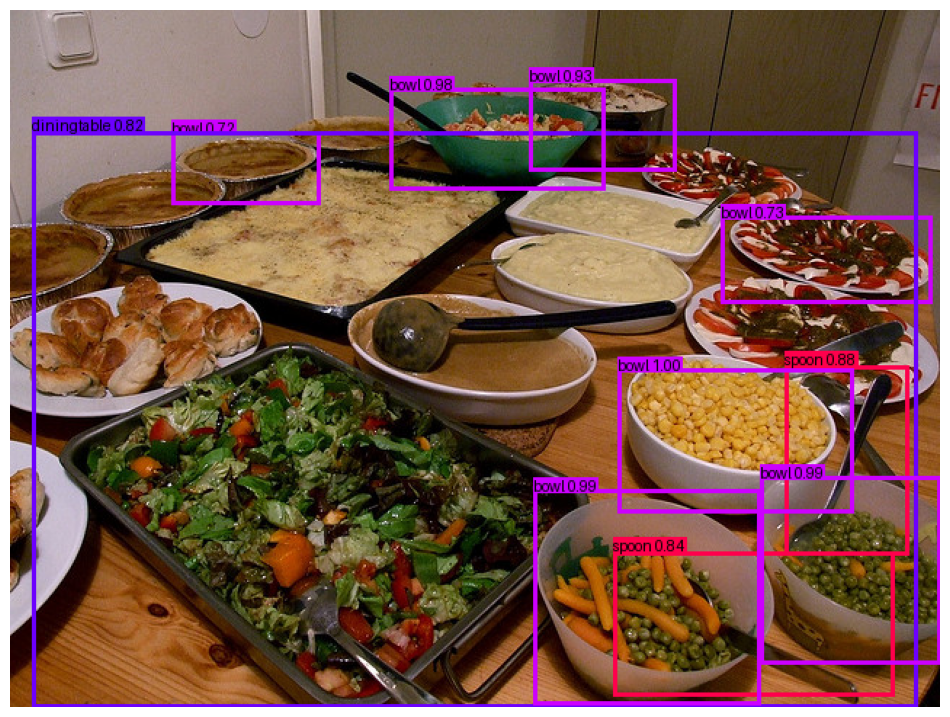

In [ ]:
executar_predicao("img/food.jpg", modelo, class_names, device)